In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
INPUT = Path("/kaggle/input")
TILES_PATH = INPUT / "datasets/edwardsx/geovision-tiles-sit2"
if not TILES_PATH.exists():
    TILES_PATH = INPUT / "geovision-tiles-sit2"

OUTPUT = Path("/kaggle/working")
FIG_DIR = OUTPUT / "figuras_tiles"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASES = [
    "contaminacion_alta_NO2",
    "contaminacion_alta_SO2",
    "ozono_anomalo",
    "vegetacion_densa",
    "suelo_urbano",
]

COLORES = {
    "contaminacion_alta_NO2": "#e74c3c",
    "contaminacion_alta_SO2": "#e67e22",
    "ozono_anomalo": "#f1c40f",
    "vegetacion_densa": "#27ae60",
    "suelo_urbano": "#7f8c8d",
}

BANDAS_OPTICAS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]
TILE_PX = 64

COLS_ERA5 = ["era5_T2m", "era5_Td2m", "era5_u10", "era5_v10", "era5_BLH", "era5_RH850", "era5_psurf", "era5_precip"]
COLS_MODIS = ["modis_AOD_047", "modis_AOD_055", "modis_WV"]
COLS_S5P = ["no2", "so2", "o3"]

In [4]:
npz = np.load(TILES_PATH / "tiles_train.npz", allow_pickle=False)
tiles = npz["data"]
bands = list(npz["bands"])
meta = pd.read_parquet(TILES_PATH / "tiles_meta.parquet")

print(f"Tiles shape: {tiles.shape}")
print(f"Bandas ({len(bands)}): {bands}")
print(f"Meta shape: {meta.shape}")
print(f"Meta columnas ({len(meta.columns)}): {list(meta.columns)}")

Tiles shape: (5000, 13, 64, 64)
Bandas (13): [np.str_('B1'), np.str_('B2'), np.str_('B3'), np.str_('B4'), np.str_('B5'), np.str_('B6'), np.str_('B7'), np.str_('B8'), np.str_('B8A'), np.str_('B9'), np.str_('B11'), np.str_('B12'), np.str_('SCL')]
Meta shape: (5000, 22)
Meta columnas (22): ['clase', 'time_s2', 'lat', 'lon', 'ndvi', 'ndbi', 'scl_pct', 'no2', 'so2', 'o3', 'texto', 'era5_T2m', 'era5_Td2m', 'era5_u10', 'era5_v10', 'era5_BLH', 'era5_RH850', 'era5_psurf', 'era5_precip', 'modis_AOD_047', 'modis_AOD_055', 'modis_WV']


In [5]:
print("Valores del npz:")
print(f"  dtype: {tiles.dtype}")
print(f"  rango: {tiles.min():.2f} a {tiles.max():.2f}")
print(f"  NaN: {np.isnan(tiles).sum()}")
print(f"  ceros: {(tiles == 0).mean()*100:.2f}%")
print()
print("Distribucion por clase:")
print(meta["clase"].value_counts().to_string())

Valores del npz:
  dtype: float32
  rango: 0.00 a 22424.00
  NaN: 0
  ceros: 0.11%

Distribucion por clase:
clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
vegetacion_densa          1000
suelo_urbano              1000


In [6]:
print(f"Rango lat: {meta['lat'].min():.4f} a {meta['lat'].max():.4f}")
print(f"Rango lon: {meta['lon'].min():.4f} a {meta['lon'].max():.4f}")
print()
print("Media lat/lon por clase:")
print(meta.groupby("clase")[["lat", "lon"]].agg(["mean", "count", "std"]).round(4).to_string())

Rango lat: 3.3029 a 3.6456
Rango lon: -76.6455 a -76.3029

Media lat/lon por clase:
                           lat                    lon              
                          mean count     std     mean count     std
clase                                                              
contaminacion_alta_NO2  3.4704  1000  0.0650 -76.4996  1000  0.0432
contaminacion_alta_SO2  3.4525  1000  0.0924 -76.4471  1000  0.0823
ozono_anomalo           3.4574  1000  0.0930 -76.4618  1000  0.0951
suelo_urbano            3.4557  1000  0.0462 -76.5075  1000  0.0224
vegetacion_densa        3.4564  1000  0.0979 -76.4462  1000  0.0990


In [7]:
PANEL_PATH = INPUT / "datasets/juanjoseorozcolopez/geovision-fuentes"
estaciones = pd.read_csv(PANEL_PATH / "dagma" / "estaciones_metadata.csv")

print("Estaciones DAGMA:")
for _, row in estaciones.iterrows():
    print(f"  {row['nombre_est']:30s} ({row['nombre_fgda']:4s})  lat={row['latitud']:.4f}  lon={row['longitud']:.4f}")

Estaciones DAGMA:
  BASE AÉREA                     (DAGMA)  lat=3.4571  lon=-76.5023
  CAÑAVERALEJO                   (DAGMA)  lat=3.4164  lon=-76.5496
  COMPARTIR                      (DAGMA)  lat=3.4283  lon=-76.4666
  ERA OBRERO                     (DAGMA)  lat=3.4573  lon=-76.5065
  ESTACIÓN YUMBO                 (CVC )  lat=3.5791  lon=-76.4896
  LA ERMITA                      (DAGMA)  lat=3.4555  lon=-76.5310
  LA FLORA                       (DAGMA)  lat=3.4882  lon=-76.5181
  PANCE                          (DAGMA)  lat=3.3045  lon=-76.5313
  TRANSITORIA-NAVARRO            (DAGMA)  lat=3.4172  lon=-76.4950
  UNIVERSIDAD DEL VALLE          (DAGMA)  lat=3.3779  lon=-76.5338


Mapa: /kaggle/working/figuras_tiles/mapa_tiles_estaciones.png


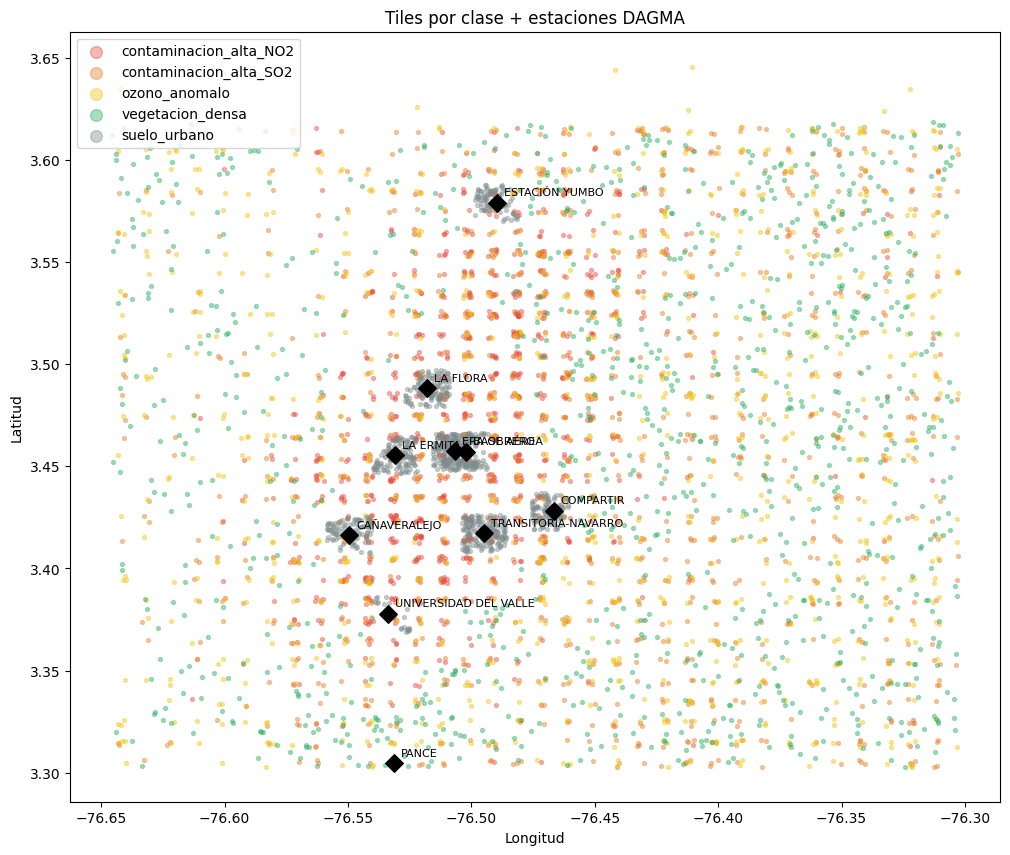

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
for clase in CLASES:
    mask = meta["clase"] == clase
    ax.scatter(meta.loc[mask, "lon"], meta.loc[mask, "lat"],
               c=COLORES[clase], label=clase[:25], alpha=0.4, s=8)
for _, row in estaciones.iterrows():
    ax.scatter(row["longitud"], row["latitud"], c="black", s=80, marker="D", zorder=5)
    ax.annotate(row["nombre_est"], (row["longitud"], row["latitud"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8, zorder=6)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title("Tiles por clase + estaciones DAGMA")
ax.legend(markerscale=3, loc="upper left")
fig.savefig(str(FIG_DIR / "mapa_tiles_estaciones.png"), dpi=150, bbox_inches="tight")
print(f"Mapa: {FIG_DIR / 'mapa_tiles_estaciones.png'}")

In [9]:
print("Estadisticas NDVI y NDBI por clase:")
for clase in CLASES:
    mask = meta["clase"] == clase
    print(f'{clase[:30]:30s} | NDVI: {meta.loc[mask, "ndvi"].mean():.3f} +/- {meta.loc[mask, "ndvi"].std():.3f} | NDBI: {meta.loc[mask, "ndbi"].mean():.3f} +/- {meta.loc[mask, "ndbi"].std():.3f}')
print()
print("Distancia entre centros (NDVI, NDBI):")
centros = meta.groupby("clase")[["ndvi", "ndbi"]].mean().values
for i, c1 in enumerate(CLASES):
    for j, c2 in enumerate(CLASES):
        if i < j:
            d = np.linalg.norm(centros[i] - centros[j])
            print(f"  {c1[:20]:20s} vs {c2[:20]:20s}: {d:.3f}")


Estadisticas NDVI y NDBI por clase:
contaminacion_alta_NO2         | NDVI: 0.384 +/- 0.190 | NDBI: -0.031 +/- 0.135
contaminacion_alta_SO2         | NDVI: 0.543 +/- 0.176 | NDBI: -0.145 +/- 0.138
ozono_anomalo                  | NDVI: 0.536 +/- 0.167 | NDBI: -0.133 +/- 0.129
vegetacion_densa               | NDVI: 0.690 +/- 0.062 | NDBI: -0.251 +/- 0.080
suelo_urbano                   | NDVI: 0.181 +/- 0.065 | NDBI: 0.093 +/- 0.054

Distancia entre centros (NDVI, NDBI):
  contaminacion_alta_N vs contaminacion_alta_S: 0.196
  contaminacion_alta_N vs ozono_anomalo       : 0.184
  contaminacion_alta_N vs vegetacion_densa    : 0.238
  contaminacion_alta_N vs suelo_urbano        : 0.377
  contaminacion_alta_S vs ozono_anomalo       : 0.013
  contaminacion_alta_S vs vegetacion_densa    : 0.433
  contaminacion_alta_S vs suelo_urbano        : 0.181
  ozono_anomalo        vs vegetacion_densa    : 0.421
  ozono_anomalo        vs suelo_urbano        : 0.194
  vegetacion_densa     vs suelo_urbano  

Scatter: /kaggle/working/figuras_tiles/ndvi_ndbi_scatter.png


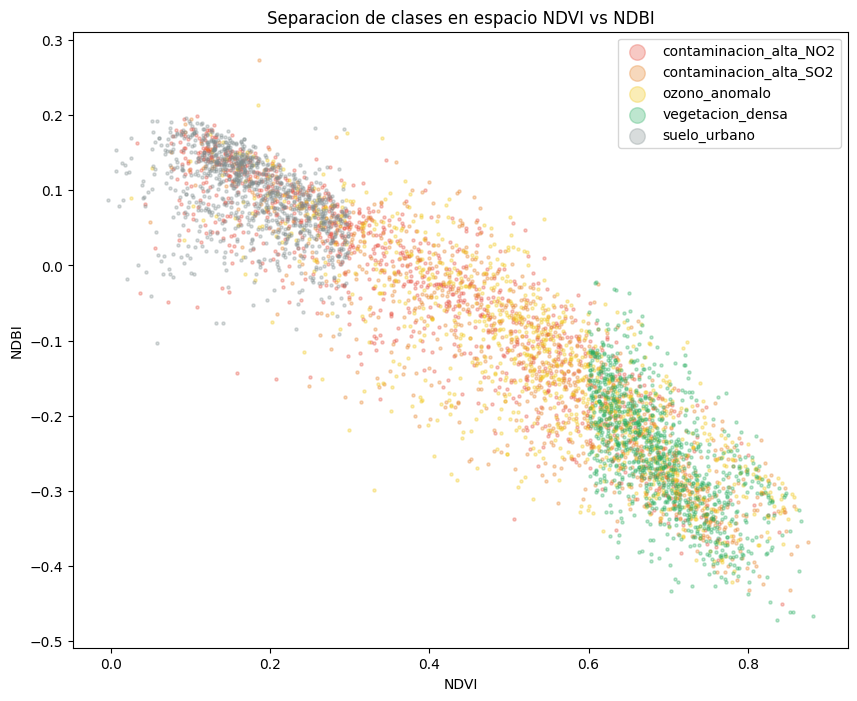

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
for clase in CLASES:
    mask = meta["clase"] == clase
    ax.scatter(meta.loc[mask, "ndvi"], meta.loc[mask, "ndbi"],
               c=COLORES[clase], label=clase[:25], alpha=0.3, s=5)
ax.set_xlabel("NDVI"); ax.set_ylabel("NDBI")
ax.set_title("Separacion de clases en espacio NDVI vs NDBI")
ax.legend(markerscale=5)
fig.savefig(str(FIG_DIR / "ndvi_ndbi_scatter.png"), dpi=130, bbox_inches="tight")
print(f"Scatter: {FIG_DIR / 'ndvi_ndbi_scatter.png'}")


In [11]:
meta["fecha_dt"] = pd.to_datetime(
    meta["time_s2"].astype(str).str.split("_").str[0],
    format="%Y%m%dT%H%M%S"
)
meta["ano"] = meta["fecha_dt"].dt.year
meta["mes"] = meta["fecha_dt"].dt.month

print("Tiles por ano y clase:")
print(pd.crosstab(meta["clase"], meta["ano"]).to_string())
print()
print("Tiles por mes calendario:")
print(pd.crosstab(meta["clase"], meta["mes"]).to_string())
print()
print("Fechas unicas por clase:")
print(meta.groupby("clase")["fecha_dt"].nunique().to_string())
print()
print("Rango temporal por clase:")
print(meta.groupby("clase")["fecha_dt"].agg(["min", "max"]).to_string())


Tiles por ano y clase:
ano                     2021  2022  2023  2024  2025
clase                                               
contaminacion_alta_NO2   153   139   191   414   103
contaminacion_alta_SO2   175   124   262   398    41
ozono_anomalo             20   342   113   517     8
suelo_urbano             290   107    97   319   187
vegetacion_densa         218    85   121   367   209

Tiles por mes calendario:
mes                      1   2   3   4   5   6    7    8    9    10  11  12
clase                                                                      
contaminacion_alta_NO2  114  55  28  19  39  19   80  156  225  172  64  29
contaminacion_alta_SO2  111  60  22  24  57  40  200  149  127  111  82  17
ozono_anomalo             0   0   0   0   0   1  108  306  401  184   0   0
suelo_urbano            152  68  19  61  78  21  121   65  124  153  87  51
vegetacion_densa        125  66  11  67  86  17  151   77  121  116  92  71

Fechas unicas por clase:
clase
contaminacion_a

Grafico: /kaggle/working/figuras_tiles/tiles_temporal.png


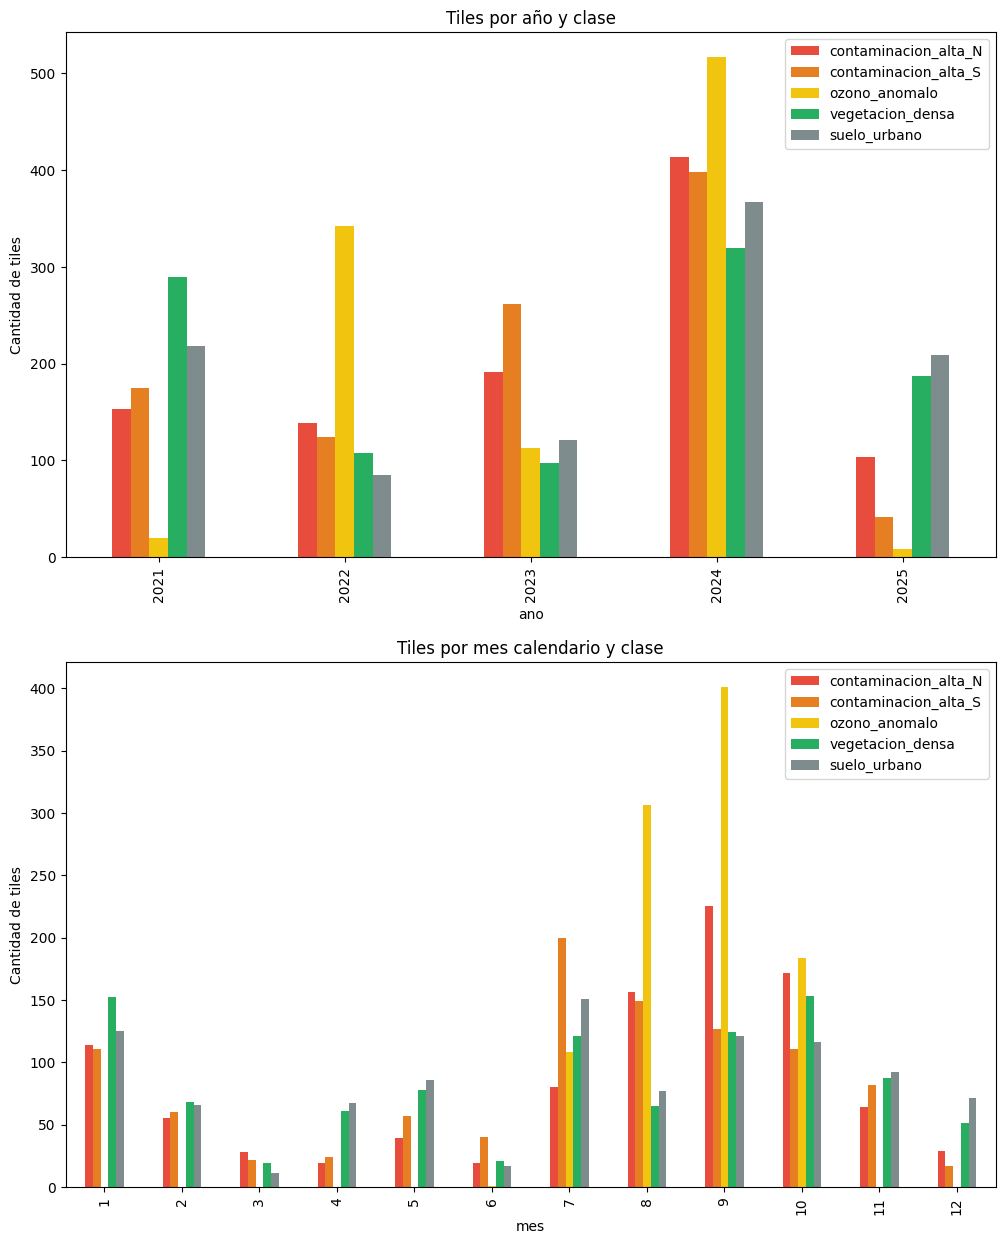

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 15))
crosstab_ano = pd.crosstab(meta["clase"], meta["ano"])
crosstab_ano.T.plot(kind="bar", ax=axes[0], color=COLORES.values())
axes[0].set_title("Tiles por año y clase")
axes[0].set_ylabel("Cantidad de tiles")
axes[0].legend(labels=[c[:20] for c in CLASES])

crosstab_mes = pd.crosstab(meta["clase"], meta["mes"])
crosstab_mes.T.plot(kind="bar", ax=axes[1], color=COLORES.values())
axes[1].set_title("Tiles por mes calendario y clase")
axes[1].set_ylabel("Cantidad de tiles")
axes[1].legend(labels=[c[:20] for c in CLASES])
fig.savefig(str(FIG_DIR / "tiles_temporal.png"), dpi=130, bbox_inches="tight")
print(f"Grafico: {FIG_DIR / 'tiles_temporal.png'}")


In [20]:
print("Cobertura MODIS por clase:")
for c in COLS_MODIS:
    print(f"\n{c}:")
    for clase in CLASES:
        mask = meta["clase"] == clase
        total = mask.sum()
        validos = meta.loc[mask, c].notna().sum()
        media = meta.loc[mask, c].mean()
        print(f"  {clase[:30]:30s} {validos:>4d}/{total} ({validos/total*100:5.1f}%) media={media:.4f}")

Cobertura MODIS por clase:

modis_AOD_047:
  contaminacion_alta_NO2          183/1000 ( 18.3%) media=0.3203
  contaminacion_alta_SO2          164/1000 ( 16.4%) media=0.3550
  ozono_anomalo                   144/1000 ( 14.4%) media=0.2508
  vegetacion_densa                154/1000 ( 15.4%) media=0.3135
  suelo_urbano                    122/1000 ( 12.2%) media=0.3431

modis_AOD_055:
  contaminacion_alta_NO2          183/1000 ( 18.3%) media=0.2319
  contaminacion_alta_SO2          164/1000 ( 16.4%) media=0.2573
  ozono_anomalo                   144/1000 ( 14.4%) media=0.1810
  vegetacion_densa                154/1000 ( 15.4%) media=0.2269
  suelo_urbano                    122/1000 ( 12.2%) media=0.2485

modis_WV:
  contaminacion_alta_NO2          978/1000 ( 97.8%) media=1.9022
  contaminacion_alta_SO2          982/1000 ( 98.2%) media=1.7464
  ozono_anomalo                   976/1000 ( 97.6%) media=1.3831
  vegetacion_densa                988/1000 ( 98.8%) media=1.9424
  suelo_urbano      

Grafico: /kaggle/working/figuras_tiles/modis_cobertura.png


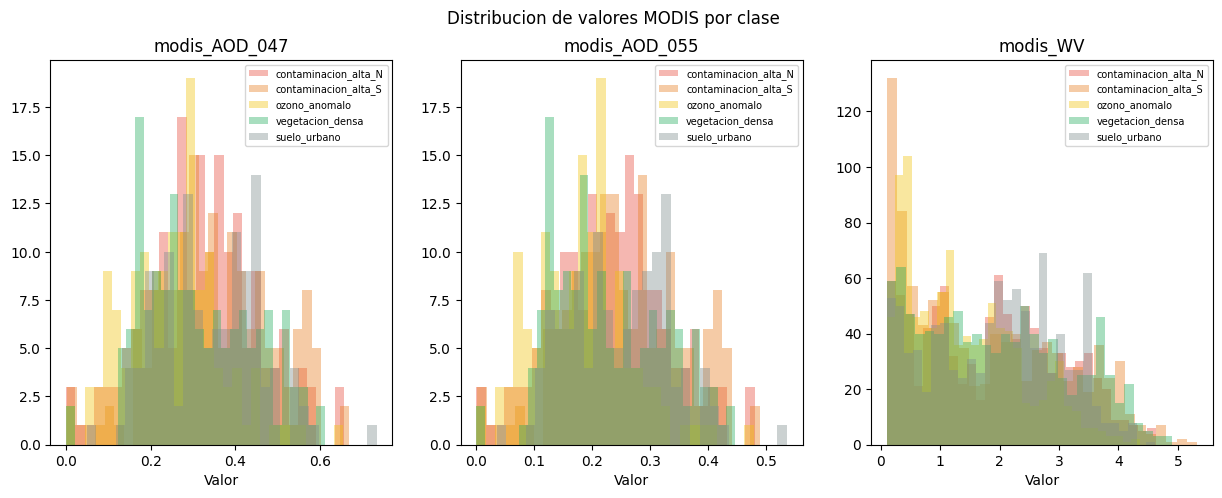

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, c in enumerate(COLS_MODIS):
    for clase in CLASES:
        mask = meta["clase"] == clase
        vals = meta.loc[mask, c].dropna()
        axes[i].hist(vals, bins=30, alpha=0.4, label=clase[:20], color=COLORES[clase])
    axes[i].set_title(c)
    axes[i].set_xlabel("Valor")
    axes[i].legend(fontsize=7)
fig.suptitle("Distribucion de valores MODIS por clase")
fig.savefig(str(FIG_DIR / "modis_cobertura.png"), dpi=130, bbox_inches="tight")
print(f"Grafico: {FIG_DIR / 'modis_cobertura.png'}")

In [25]:
print("Estadisticas de pseudo-labels S5P por clase:")
for col in COLS_S5P:
    print(f"\n{col} (mol/m2):")
    for clase in CLASES:
        vals = meta.loc[meta["clase"] == clase, col].dropna()
        if len(vals) > 0:
            print(f"  {clase[:30]:30s} n={len(vals):>4d}  media={vals.mean():.6f}  p50={vals.median():.6f}  p90={vals.quantile(0.9):.6f}  p99={vals.quantile(0.99):.6f}")


Estadisticas de pseudo-labels S5P por clase:

no2 (mol/m2):
  contaminacion_alta_NO2         n=1000  media=0.000074  p50=0.000068  p90=0.000100  p99=0.000154

so2 (mol/m2):
  contaminacion_alta_SO2         n=1000  media=0.000592  p50=0.000526  p90=0.000829  p99=0.001498

o3 (mol/m2):
  ozono_anomalo                  n=1000  media=0.126670  p50=0.126768  p90=0.129200  p99=0.130578


Grafico: /kaggle/working/figuras_tiles/s5p_pseudolabels.png


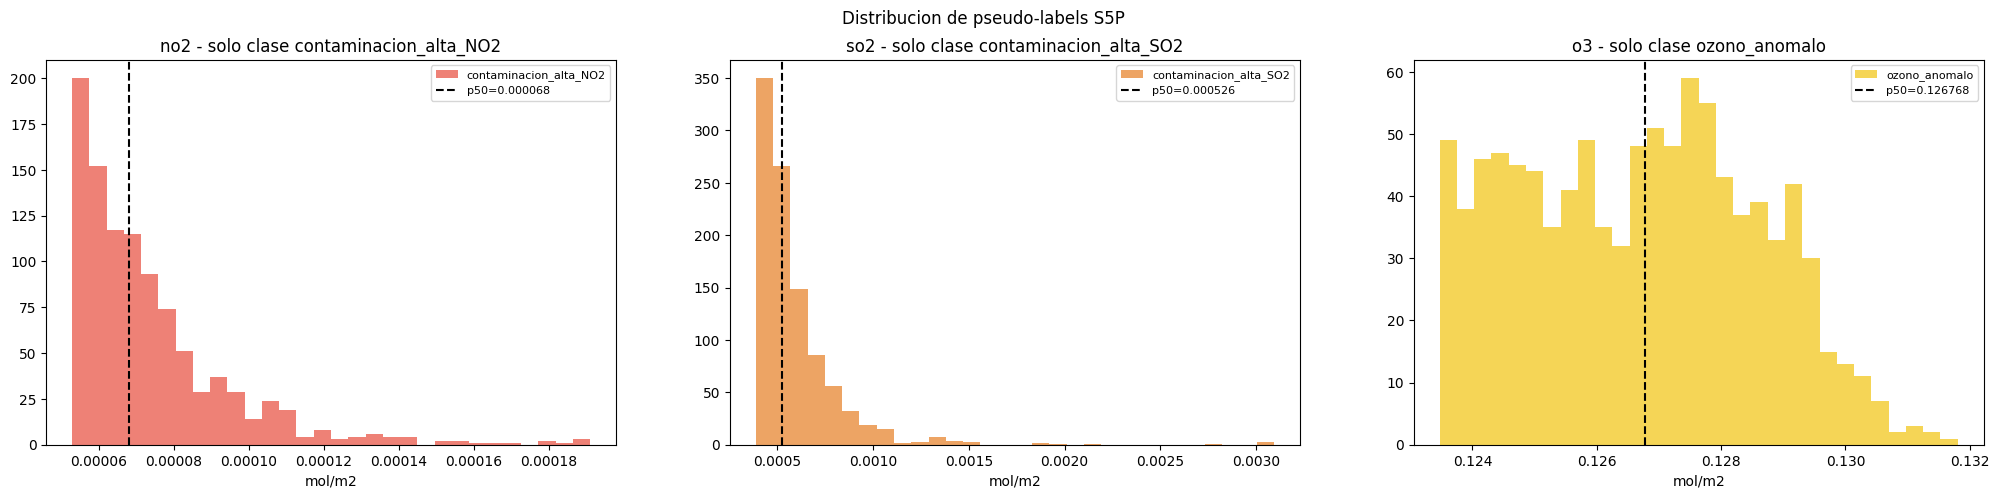

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5))
mapa_col_clase = {"no2": "contaminacion_alta_NO2", "so2": "contaminacion_alta_SO2", "o3": "ozono_anomalo"}
for i, col in enumerate(COLS_S5P):
    clase = mapa_col_clase[col]
    vals = meta.loc[meta["clase"] == clase, col]
    axes[i].hist(vals, bins=30, alpha=0.7, color=COLORES[clase], label=clase)
    axes[i].axvline(vals.median(), color="black", ls="--", label=f"p50={vals.median():.6f}")
    axes[i].set_title(f"{col} - solo clase {clase}")
    axes[i].set_xlabel("mol/m2")
    axes[i].legend(fontsize=8)
fig.suptitle("Distribucion de pseudo-labels S5P")
fig.savefig(str(FIG_DIR / "s5p_pseudolabels.png"), dpi=130, bbox_inches="tight")
print(f"Grafico: {FIG_DIR / 's5p_pseudolabels.png'}")